# Algorithmic Trading tracker for S&P500 dividend using yfinance fetcher library and automatized report generator.

In [ ]:
import os
import numpy as np
import pandas as pd
import plotly as py
import plotly.io as pio
import plotly.graph_objects as go
import plotly.express as px
from datetime import timedelta, datetime
from plotly.subplots import make_subplots
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

In [ ]:
import yfinance as yf
from datetime import datetime

# S&P 500 ticker symbol
sp500_ticker = '^GSPC'

# Set up End and Start times for data grab
end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

# Download S&P 500 data using yfinance
sp500_data = yf.download(sp500_ticker, start=start, end=end)

# Display the data
print(sp500_data.tail())

[*********************100%***********************]  1 of 1 completed

                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2024-10-04  5737.479980  5753.209961  5702.830078  5751.069824  5751.069824   
2024-10-07  5737.799805  5739.339844  5686.850098  5695.939941  5695.939941   
2024-10-08  5719.140137  5757.600098  5714.560059  5751.129883  5751.129883   
2024-10-09  5751.799805  5796.799805  5745.020020  5792.040039  5792.040039   
2024-10-10  5778.359863  5795.029785  5764.759766  5780.049805  5780.049805   

                Volume  
Date                    
2024-10-04  3479400000  
2024-10-07  3637790000  
2024-10-08  3393400000  
2024-10-09  3650340000  
2024-10-10  2091866000  


In [ ]:
# Summary statistics
sp500_data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,253.000000,253.000000,253.000000,253.000000,253.000000,2.530000e+02
mean,5102.539082,5125.395546,5078.981897,5104.182609,5104.182609,3.900974e+09
std,426.188669,426.912544,422.685228,424.790434,424.790434,7.460738e+08
min,4139.390137,4156.700195,4103.779785,4117.370117,4117.370117,1.639500e+09
25%,4772.350098,4785.790039,4751.990234,4780.240234,4780.240234,3.544330e+09
50%,5164.459961,5180.310059,5138.700195,5165.310059,5165.310059,3.818880e+09
75%,5466.770020,5489.459961,5434.490234,5463.540039,5463.540039,4.051710e+09
max,5778.359863,5796.799805,5764.759766,5792.040039,5792.040039,8.218980e+09


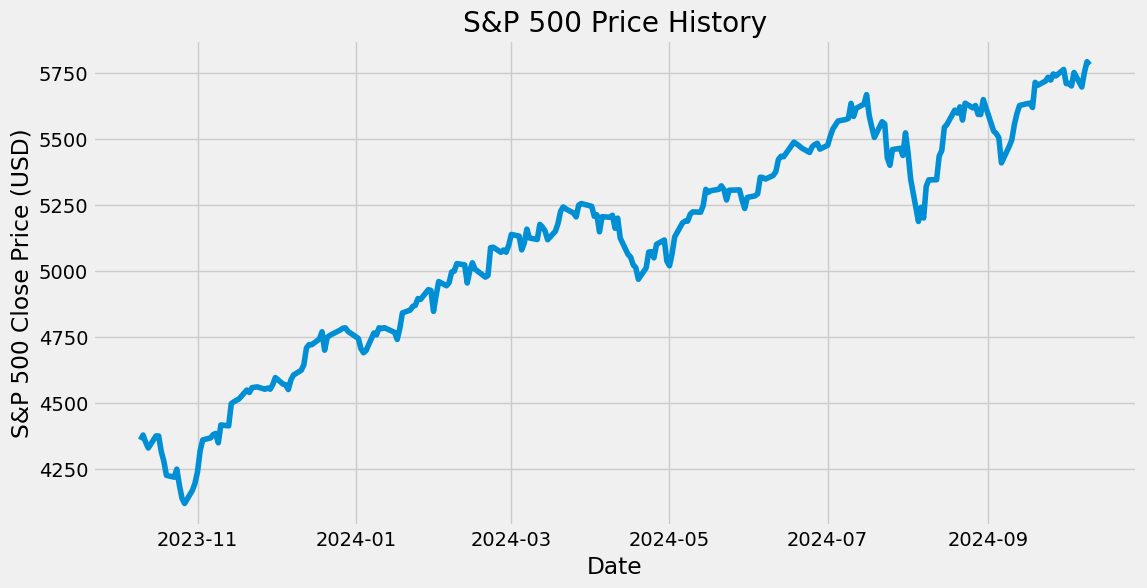

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.title('S&P 500 Price History')
plt.plot(sp500_data['Close'])
plt.xlabel('Date')
plt.ylabel('S&P 500 Close Price (USD)')
plt.show()

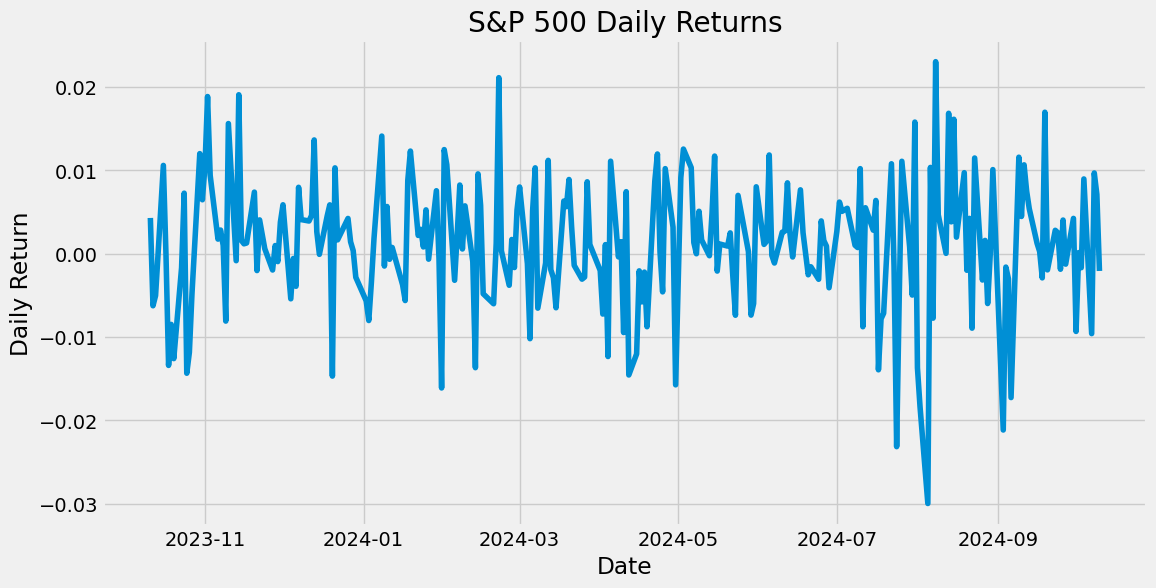

<Figure size 640x480 with 0 Axes>

In [ ]:
sp500_data['Daily Return'] = sp500_data['Close'].pct_change()

# Plot daily returns
plt.figure(figsize=(12,6))
plt.title('S&P 500 Daily Returns')
plt.plot(sp500_data['Daily Return'])
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()
plt.savefig('S&P 500 Daily Returns.png')

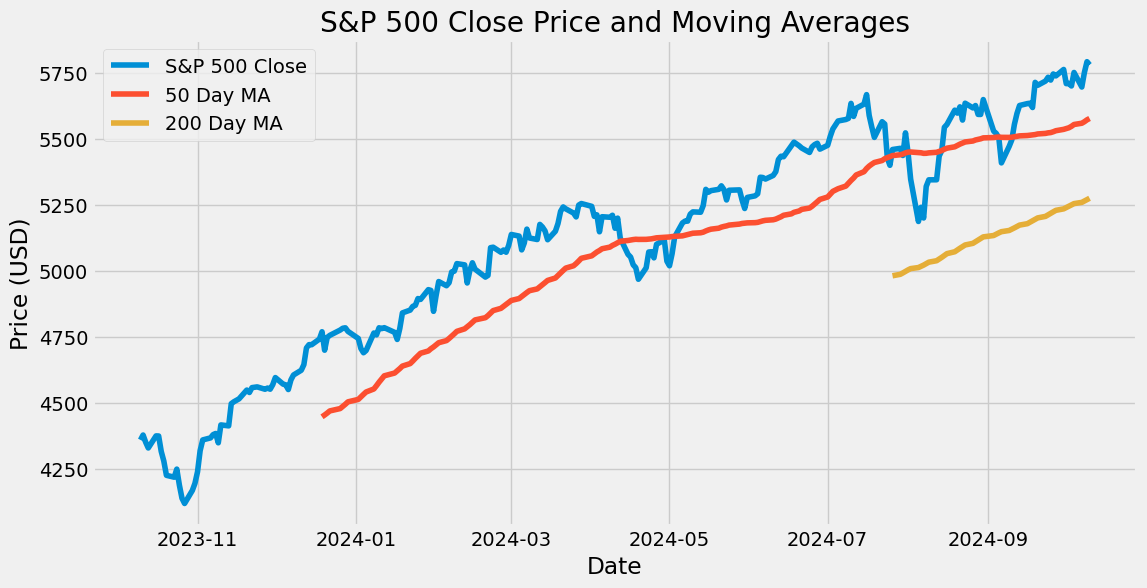

<Figure size 640x480 with 0 Axes>

In [ ]:
sp500_data['50 Day MA'] = sp500_data['Close'].rolling(window=50).mean()
sp500_data['200 Day MA'] = sp500_data['Close'].rolling(window=200).mean()

# Plot moving averages
plt.figure(figsize=(12,6))
plt.plot(sp500_data['Close'], label='S&P 500 Close')
plt.plot(sp500_data['50 Day MA'], label='50 Day MA')
plt.plot(sp500_data['200 Day MA'], label='200 Day MA')
plt.legend()
plt.title('S&P 500 Close Price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()
plt.savefig('S&P 500 Close Price and Moving Averages.png')

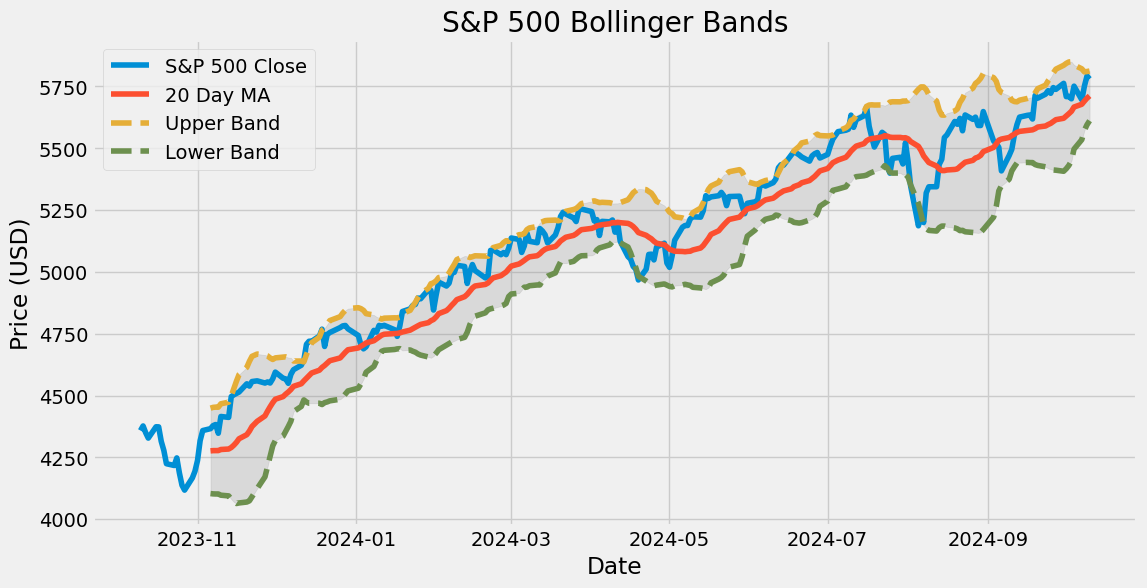

<Figure size 640x480 with 0 Axes>

In [ ]:
sp500_data['20 Day MA'] = sp500_data['Close'].rolling(window=20).mean()
sp500_data['Upper Band'] = sp500_data['20 Day MA'] + (sp500_data['Close'].rolling(window=20).std() * 2)
sp500_data['Lower Band'] = sp500_data['20 Day MA'] - (sp500_data['Close'].rolling(window=20).std() * 2)

# Plot Bollinger Bands
plt.figure(figsize=(12,6))
plt.plot(sp500_data['Close'], label='S&P 500 Close')
plt.plot(sp500_data['20 Day MA'], label='20 Day MA')
plt.plot(sp500_data['Upper Band'], label='Upper Band', linestyle='--')
plt.plot(sp500_data['Lower Band'], label='Lower Band', linestyle='--')
plt.fill_between(sp500_data.index, sp500_data['Lower Band'], sp500_data['Upper Band'], color='gray', alpha=0.2)
plt.legend()
plt.title('S&P 500 Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()
plt.savefig('S&P 500 Bollinger Bands.png')

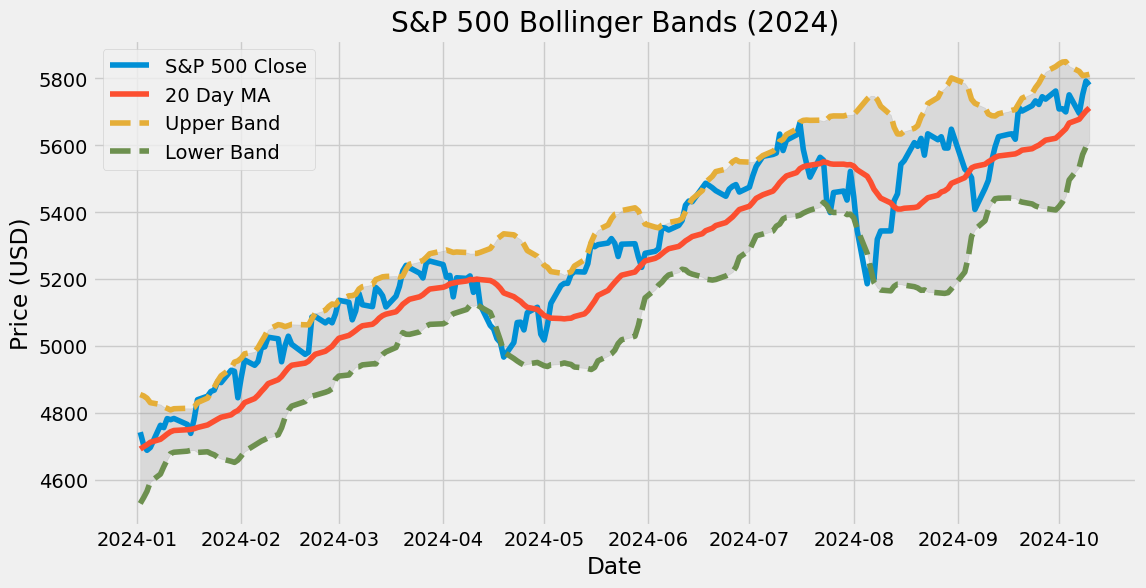

<Figure size 640x480 with 0 Axes>

In [ ]:
# Filter data for 2024 only
sp500_2024 = sp500_data.loc['2024']

# Plot Bollinger Bands for 2024
plt.figure(figsize=(12,6))
plt.plot(sp500_2024['Close'], label='S&P 500 Close')
plt.plot(sp500_2024['20 Day MA'], label='20 Day MA')
plt.plot(sp500_2024['Upper Band'], label='Upper Band', linestyle='--')
plt.plot(sp500_2024['Lower Band'], label='Lower Band', linestyle='--')
plt.fill_between(sp500_2024.index, sp500_2024['Lower Band'], sp500_2024['Upper Band'], color='gray', alpha=0.2)
plt.legend()
plt.title('S&P 500 Bollinger Bands (2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()
plt.savefig('S&P 500 Bollinger Bands (2024).png')

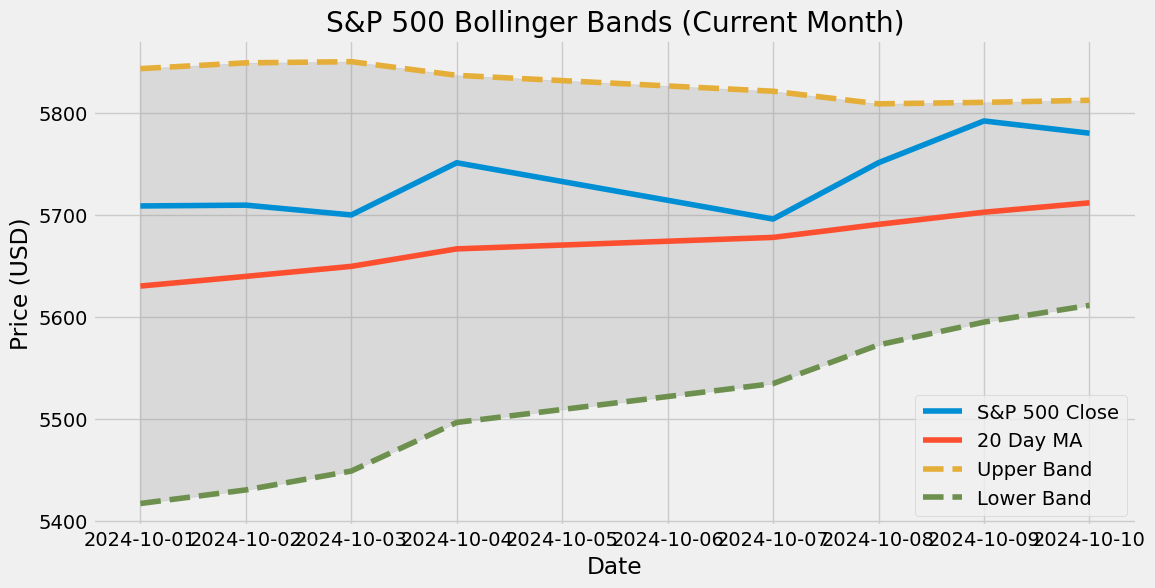

<Figure size 640x480 with 0 Axes>

In [ ]:
# Filter for current month (October 2024 in this example)
current_month = datetime.now().strftime('%Y-%m')
sp500_current_month = sp500_data.loc[current_month]

# Plot Bollinger Bands for the current month
plt.figure(figsize=(12,6))
plt.plot(sp500_current_month['Close'], label='S&P 500 Close')
plt.plot(sp500_current_month['20 Day MA'], label='20 Day MA')
plt.plot(sp500_current_month['Upper Band'], label='Upper Band', linestyle='--')
plt.plot(sp500_current_month['Lower Band'], label='Lower Band', linestyle='--')
plt.fill_between(sp500_current_month.index, sp500_current_month['Lower Band'], sp500_current_month['Upper Band'], color='gray', alpha=0.2)
plt.legend()
plt.title('S&P 500 Bollinger Bands (Current Month)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()
plt.savefig('S&P 500 Bollinger Bands (Current Month).png')

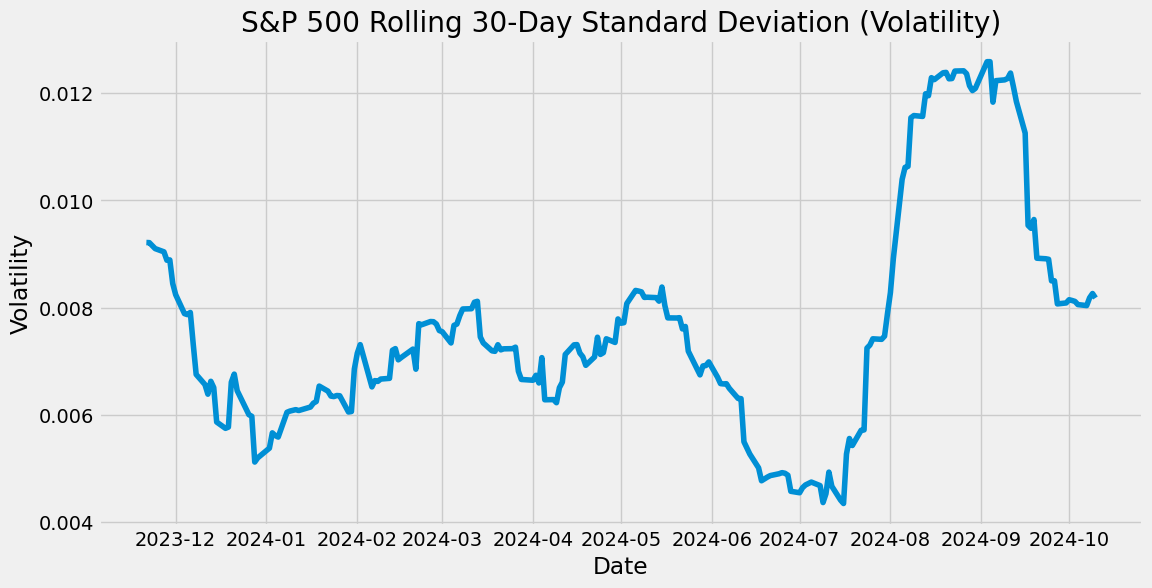

<Figure size 640x480 with 0 Axes>

In [ ]:
sp500_data['Rolling Std Dev'] = sp500_data['Daily Return'].rolling(window=30).std()

# Plot rolling standard deviation (volatility)
plt.figure(figsize=(12,6))
plt.plot(sp500_data['Rolling Std Dev'])
plt.title('S&P 500 Rolling 30-Day Standard Deviation (Volatility)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()
plt.savefig('S&P 500 Rolling 30-Day Standard Deviation (Volatility).png')

In [ ]:
# Assuming risk-free rate is 0
sharpe_ratio = sp500_data['Daily Return'].mean() / sp500_data['Daily Return'].std()
print(f'Sharpe Ratio: {sharpe_ratio}')

Sharpe Ratio: 0.1461889607595876


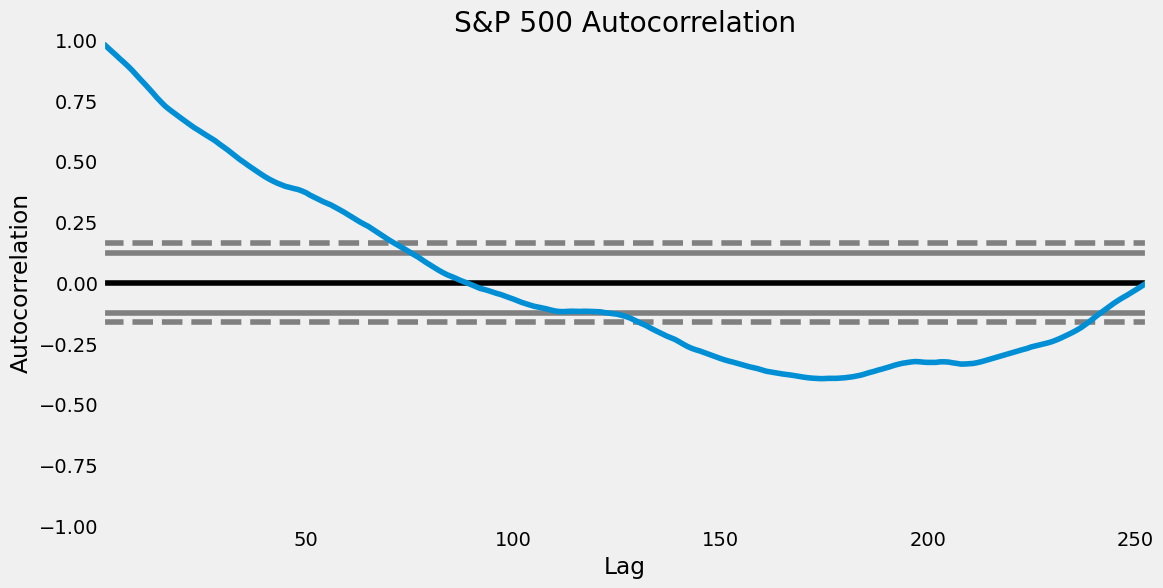

<Figure size 640x480 with 0 Axes>

In [ ]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(12,6))
autocorrelation_plot(sp500_data['Close'])
plt.title('S&P 500 Autocorrelation')
plt.show()
plt.savefig('S&P 500 Autocorrelation.png')

# Automated Report Generator

A full exportable report can be generated using:

In [ ]:
!pip install weasyprint pandas matplotlib

In [ ]:
summary = sp500_data.describe()

# Key insights
bollinger_summary = {
    "20 Day MA": sp500_data['20 Day MA'].iloc[-1],
    "Upper Band": sp500_data['Upper Band'].iloc[-1],
    "Lower Band": sp500_data['Lower Band'].iloc[-1]
}

volatility_summary = sp500_data['Rolling Std Dev'].iloc[-1]

In [ ]:
#HTML transform of images
from weasyprint import HTML

html_template = f"""
<html>
<head><title>S&P 500 Report</title></head>
<body>
<h1>S&P 500 Analysis Report</h1>

<h2>Price History</h2>
<img src="sp500_price_history.png" width="600">

<h2>Daily Returns</h2>
<img src="sp500_daily_returns.png" width="600">

<h2>Moving Averages</h2>
<img src="sp500_moving_averages.png" width="600">

<h2>Bollinger Bands</h2>
<img src="sp500_bollinger_bands.png" width="600">

<h2>Volatility (Rolling Std Dev)</h2>
<img src="sp500_volatility.png" width="600">

<h2>Autocorrelation</h2>
<img src="sp500_autocorrelation.png" width="600">

</body>
</html>
"""

# Save HTML report
with open("report.html", "w") as f:
    f.write(html_template)

# Generate PDF from HTML
HTML('report.html').write_pdf('/content/SP500_report.pdf')

In [ ]:
#download script

from datetime import datetime
from weasyprint import HTML

# Get the current date in the desired format (e.g., YYYY-MM-DD)
current_date = datetime.now().strftime("%d%m%Y")

# Set the final file name with the current date
file_name = f"SP500_report_{current_date}.pdf"

# Generate the PDF with the new file name
HTML('report.html').write_pdf(f'/content/{file_name}')

# Trigger the download of the PDF with the new file name
from google.colab import files
files.download(f'/content/{file_name}')

print(f"Download completed: {file_name}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download completed: SP500_report_10102024.pdf
